In [1]:
## IMPORTS 
import os
import sys 
current_dir = os.getcwd()
LOCSCALE_2_SCRIPTS_PATH = os.path.dirname(current_dir)
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from scipy import stats
import pandas as pd
import seaborn as sns
from scripts.utils.plot_utils import plot_correlations
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist


random.seed(42)
np.random.seed(42)

PLOT_DATA_STORE_PATH = setup_environment(current_dir)

Data already exists. Skipping download.
Sourcing data from: /home/abharadwaj1/thesis/publications/notebooks/LocScale2.0_NComms_2026_plotData
--------------------------------------------------------------------------------


In [18]:
xfsc_0282_csv = os.path.join(PLOT_DATA_STORE_PATH, "s7_G_cross_FSC_0282.csv")
xfsc_0282_df = pd.read_csv(xfsc_0282_csv)


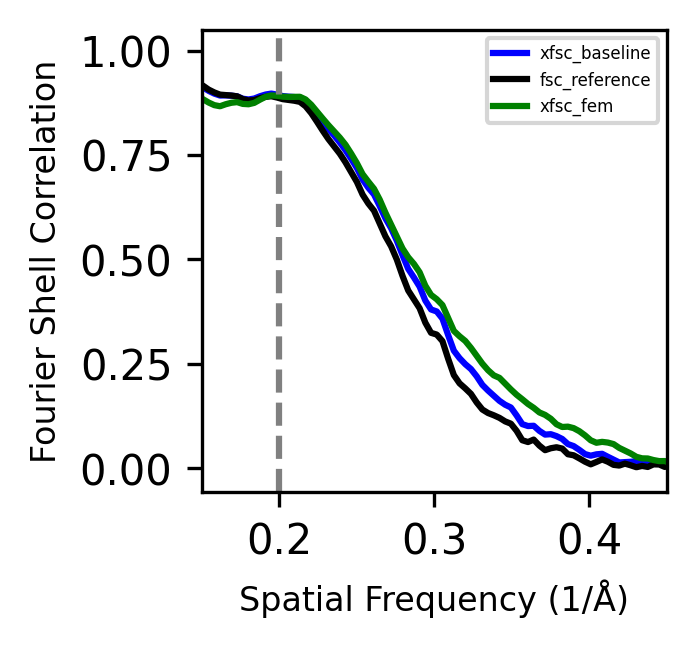

In [16]:
fig, ax = plt.subplots(figsize=(2, 2), dpi=300)
sns.lineplot(
    data=xfsc_0282_df, x="frequency", y="fsc_value", ax=ax,
    hue="curve_type",
    palette={"fsc_reference": "black", "xfsc_baseline": "blue", "xfsc_fem": "green"},
)
ax.set_xlabel("Spatial Frequency (1/Å)", fontsize=8)
ax.set_ylabel("Fourier Shell Correlation", fontsize=8)
ax.legend(fontsize=4)
ax.axvline(x=0.2, color='gray', linestyle='--')
ax.set_xlim(0.15, 0.45)
ax.set_xticks([0.2, 0.3, 0.4])


In [30]:
improvement_data_csv = os.path.join(PLOT_DATA_STORE_PATH, "s7_H_improvement_emdb.csv")
improvement_data_df = pd.read_csv(improvement_data_csv)

/tmp/ipykernel_2939/879482476.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=6);


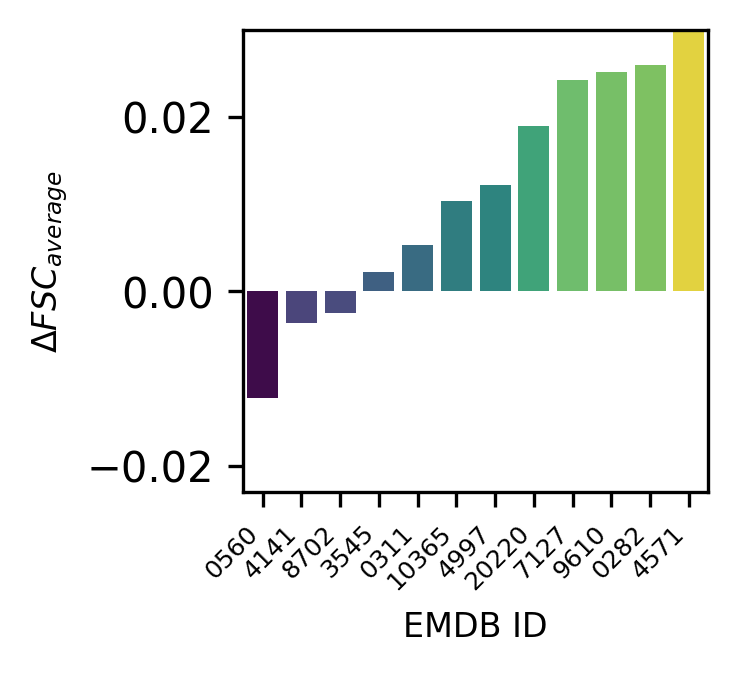

In [39]:
desired_order = ['0560', '4141', '8702', '3545', '0311', '10365', '4997', '20220', '7127', '9610', '0282', '4571']

# Ensure EMDB_ID is string, then enforce order
improvement_data_df['EMDB_ID'] = improvement_data_df['EMDB_ID'].astype(str).str.zfill(4)  # normalise padding if needed
improvement_data_df['EMDB_ID'] = pd.Categorical(improvement_data_df['EMDB_ID'], categories=desired_order, ordered=True)
improvement_data_df = improvement_data_df.sort_values('EMDB_ID')

fig, ax = plt.subplots(figsize=(2, 2), dpi=300)
sns.barplot(data=improvement_data_df, x="EMDB_ID", y="FSC_Improvement", ax=ax, hue="FSC_Improvement", palette="viridis");
ax.set_xlabel("EMDB ID", fontsize=8);
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=6);
ax.set_ylabel(r"$\Delta FSC_{average}$", fontsize=8);
# hide legend
ax.legend().set_visible(False)
ax.set_ylim(-0.023, 0.03);
ax.set_yticks([-0.02, 0, 0.02]);